In [27]:
import copy

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, max_error, r2_score, explained_variance_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import pandas as pd

In [3]:
data = pd.read_csv("data/data_preprocessed.csv")
data.head()

,Release_Period,Whether_Remake,Whether_Franchise,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR),Genre_action,Genre_comedy,Genre_drama,Genre_love_story,Genre_other,Genre_thriller
0,1,0,0,1,1,1,5,5000000,85000,0,0,0,0,1,0
1,0,0,0,0,1,0,75,15000000,825000,0,0,1,0,0,0
2,0,0,0,1,1,1,525,75000000,56700000,0,0,0,0,0,1
3,0,0,0,0,1,1,800,210000000,4500000,0,0,1,0,0,0
4,0,0,0,0,0,0,1,1000000,1075000,0,0,0,0,1,0


In [4]:
target = data["Revenue(INR)"]
features = data.drop(columns=["Revenue(INR)"])

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2)

In [5]:
features = {
    "train": features_train,
    "test": features_test
}

target = {
    "train": target_train,
    "test": target_test
}

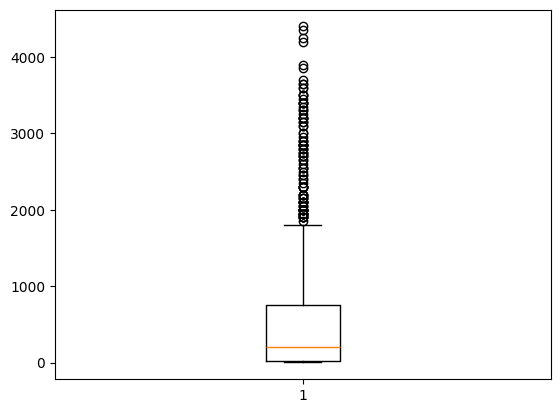

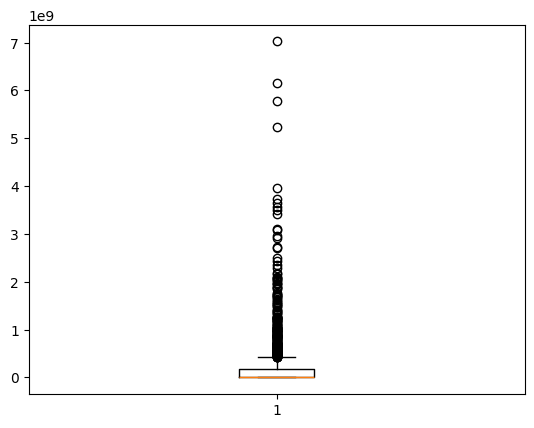

(1358, 14)

In [6]:
continuous_columns = ["Number_of_Screens", "Budget(INR)"]

for column in continuous_columns:
    plt.boxplot(features['train'][column])
    plt.show()

features["train"].shape

In [7]:
features_dropped = copy.deepcopy(features)
target_dropped = copy.deepcopy(target)

for column in continuous_columns:
    q = features["train"][column].quantile(0.95)
    drop_mask = features_dropped["train"][column] < q

    features_dropped = {
        "train": features_dropped["train"][drop_mask],
        "test": features_dropped["test"]
    }

    target_dropped = {
        "train": target_dropped["train"][drop_mask],
        "test": target_dropped["test"]
    }

features_dropped["train"].shape

(1267, 14)

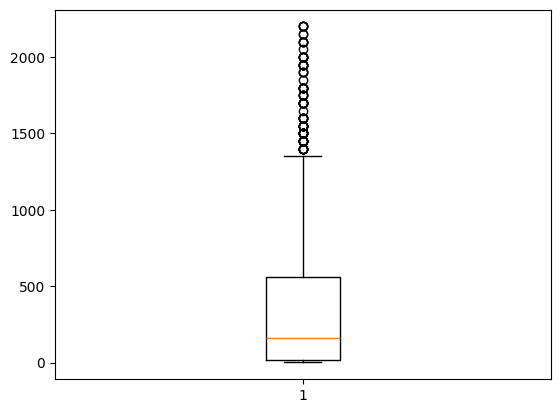

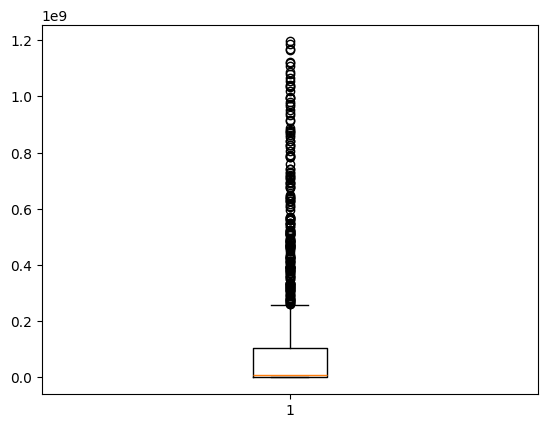

In [8]:
for column in continuous_columns:
    plt.boxplot(features_dropped['train'][column])
    plt.show()

In [9]:
feature_scaler = MinMaxScaler()
features_scaled = {
    "train": pd.DataFrame(feature_scaler.fit_transform(features_dropped["train"]), columns=features_dropped["train"].columns),
    "test": pd.DataFrame(feature_scaler.transform(features_dropped['test']), columns=features_dropped["train"].columns)
}

target_scaler = MinMaxScaler()
target_scaled = {
    "train": target_scaler.fit_transform(target_dropped["train"].to_numpy().reshape(-1, 1)),
    "test": target_scaler.transform(target_dropped["test"].to_numpy().reshape(-1, 1))
}

features_scaled["train"]

,Release_Period,Whether_Remake,Whether_Franchise,Lead_Star,Director,Music_Director,Number_of_Screens,Budget(INR),Genre_action,Genre_comedy,Genre_drama,Genre_love_story,Genre_other,Genre_thriller
0,0.0,0.0,0.0,1.0,1.0,1.0,0.135971,0.053636,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,1.0,0.0,0.818099,0.208918,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,1.0,1.0,0.681673,0.525568,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.024557,0.001291,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,1.0,1.0,0.192815,0.025909,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1262,0.0,0.0,0.0,0.0,0.0,0.0,0.003183,0.000538,0.0,0.0,1.0,0.0,0.0,0.0
1263,1.0,0.0,0.0,0.0,1.0,1.0,0.013188,0.000684,0.0,1.0,0.0,0.0,0.0,0.0
1264,0.0,0.0,0.0,0.0,1.0,0.0,0.022283,0.000684,0.0,0.0,1.0,0.0,0.0,0.0
1265,0.0,0.0,0.0,1.0,1.0,1.0,0.181446,0.355537,0.0,0.0,1.0,0.0,0.0,0.0


In [29]:
model_types = ["Random forest", "SVM", "MLP"]

algorithm_parameters = {
    "Random forest": {
        "n_estimators": range(10, 310, 20),
        "max_depth": [5, 10, 50, 100, None],
        "min_samples_split": [2, 3, 5, 10, 50]
    },
    "SVM":{
        "kernel": ("linear", "poly", "rbf", "sigmoid"),
        "degree": range(3, 6),
        "gamma": ("scale", "auto")
    },
    "MLP":{
        "activation": ("identity", "logistic", "tanh", "relu"),
        "solver": ("lbfgs", "sgd", "adam"),

    }
}

predictions = {model_type: np.empty(0) for model_type in model_types}

In [ ]:
svm = SVR()
svm_clf = GridSearchCV(svm, algorithm_parameters["SVM"])

svm_clf.fit(features_scaled["train"], target_scaled["train"].ravel())
predictions["SVM"] = svm_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [31]:
random_forest = RandomForestRegressor()
random_forest_clf = GridSearchCV(random_forest, algorithm_parameters["Random forest"])

random_forest_clf.fit(features_scaled["train"], target_scaled["train"].ravel())
predictions["Random forest"] = random_forest_clf.predict(features_scaled["test"]).reshape(-1, 1)

In [32]:
mlp = MLPRegressor()
mlp_clf = GridSearchCV(mlp, algorithm_parameters["MLP"])

mlp_clf.fit(features_scaled["train"], target_scaled["train"].ravel())
predictions["MLP"] = mlp_clf.predict(features_scaled["test"]).reshape(-1, 1)

/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/a.yasinetski/Study/bollywood/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: C

In [33]:
def regression_report(y_true, predictions, model_type):   
    metrics = [
        ('mean absolute error', mean_absolute_error(y_true, predictions[model_type])),
        ('median absolute error', median_absolute_error(y_true, predictions[model_type])),
        ('mean squared error', mean_squared_error(y_true, predictions[model_type])),
        ('max error', max_error(y_true, predictions[model_type])),
        ('r2 score', r2_score(y_true, predictions[model_type])),
        ('explained variance score', explained_variance_score(y_true, predictions[model_type]))
    ]
    
    print(f'Metrics for regression {model_type}:')

    for metric_name, metric_value in metrics:
        print(f'{metric_name:>25s}: {metric_value: >20.3f}')
    
    print("\n")

In [34]:
for model_type in model_types:
    regression_report(target_scaled["test"], predictions, model_type)

Metrics for regression Random forest:
      mean absolute error:                0.043
    median absolute error:                0.013
       mean squared error:                0.013
                max error:                1.204
                 r2 score:                0.607
 explained variance score:                0.608


Metrics for regression SVM:
      mean absolute error:                0.051
    median absolute error:                0.048
       mean squared error:                0.005
                max error:                0.373
                 r2 score:                0.865
 explained variance score:                0.882


Metrics for regression MLP:
      mean absolute error:                0.035
    median absolute error:                0.017
       mean squared error:                0.004
                max error:                0.428
                 r2 score:                0.895
 explained variance score:                0.898




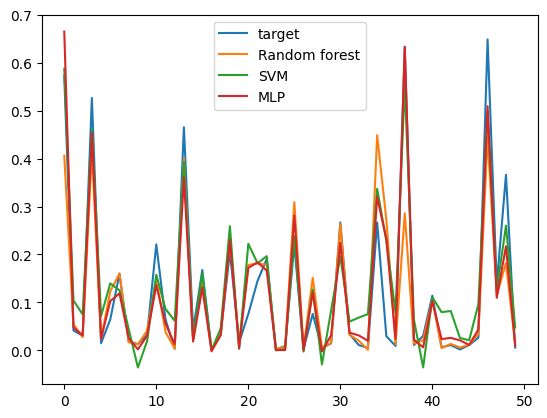

In [35]:
plt.plot(target_scaled["test"][:50], label="target")

for model_type in model_types:
    plt.plot(predictions[model_type][:50], label=model_type)

plt.legend()
plt.show()

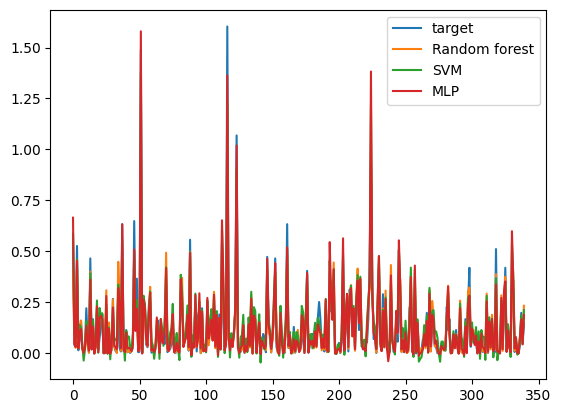

In [36]:
plt.plot(target_scaled["test"], label="target")

for model_type in model_types:
    plt.plot(predictions[model_type], label=model_type)

plt.legend()
plt.show()